# Week 3 — Matrix Decompositions

This notebook covers the third week of the AI engineering journey: breaking matrices apart into simpler, more meaningful pieces. By the end of this week, expressions like `A = Q · Λ · Q⁻¹`, `A = Q · Λ · Qᵀ`, and `A = U · Σ · Vᵀ` stop being abstract — they reveal the underlying structure of any matrix you encounter.

**Topics covered:**
1. Eigendecomposition — rewriting any diagonalizable matrix in its natural coordinate system
2. Symmetric matrices and the spectral theorem — the cleanest decomposition for the best-behaved class of matrices
3. Singular Value Decomposition (SVD) — the universal decomposition that works for every matrix
4. Low-rank approximation — using SVD to compress, denoise, and exploit hidden structure
5. Synthesis — when to use which decomposition

**Approach:** every decomposition is built from intuition (geometric where possible), then implemented in NumPy, with quant-flavored connections where they fit naturally.

**The arc of the week:** each day either extends the previous decomposition to a broader class of matrices, or applies it to a real-world problem. Eigendecomposition works for diagonalizable matrices; the spectral theorem extends it to a clean special case (symmetric); SVD generalizes everything to all matrices; and low-rank approximation exploits the resulting structure for practical compression.

## 1. Eigendecomposition

For any square matrix A with a complete set of linearly independent eigenvectors, we can decompose it as:

> **A = Q · Λ · Q⁻¹**

where:
- **Q** has the eigenvectors of A as its columns
- **Λ** is a diagonal matrix containing the eigenvalues
- **Q⁻¹** is the inverse of Q

### Geometric meaning

Read `A @ v = Q · Λ · Q⁻¹ · v` from right to left:
1. **Q⁻¹ @ v** — rotate v into the eigenvector basis (the natural coordinate system of A)
2. **Λ @ (Q⁻¹ @ v)** — scale each coordinate by the corresponding eigenvalue (pure scaling, no rotation)
3. **Q @ (Λ Q⁻¹ v)** — rotate back to the standard basis

So a complicated transformation A becomes "rotate → stretch → rotate back" — three simple operations in sequence.

### Why this is useful

Once A = Q · Λ · Q⁻¹, raising A to a power becomes trivial:

> **A^n = Q · Λ^n · Q⁻¹**

Since Λ is diagonal, Λ^n is just powering each diagonal entry — no expensive matrix multiplication required.

### The limitation

Not every matrix has a complete set of eigenvectors. Matrices that don't are called **defective**, and eigendecomposition fails for them. This limitation is exactly what motivates SVD later in the week.

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Compute the eigendecomposition of a 2x2 matrix
A = np.array([[4, 1],
              [2, 3]])

eigenvalues, eigenvectors = np.linalg.eig(A)

# Build Q, Λ, Q⁻¹ and verify A = Q · Λ · Q⁻¹
Q = eigenvectors
Lambda = np.diag(eigenvalues)
Q_inv = np.linalg.inv(Q)

A_reconstructed = Q @ Lambda @ Q_inv
print('\nMatches original?', np.allclose(A, A_reconstructed))


Matches original? True


In [4]:
# One fo the payoff of eigen decompsotion is  efficient computation of A^10

A_float = A.astype(float)

# Method 1: brute force matrix multiplication
A_10_brute = np.linalg.matrix_power(A_float, 10)

# Method 2: via eigendecomposition — just power the diagonal
Lambda_10 = np.diag(eigenvalues ** 10)
A_10_decomp = Q @ Lambda_10 @ Q_inv

print('Both methods agree?', np.allclose(A_10_brute, A_10_decomp))

Both methods agree? True


In [6]:
# Eigen decomposition failed in the case of a defective matrix as it has only one independent eigenvector
N = np.array([[2, 1],
              [0, 2]])

eigenvalues_N, eigenvectors_N = np.linalg.eig(N)
rank_of_eigvecs = np.linalg.matrix_rank(eigenvectors_N)


print('Defective?', rank_of_eigvecs < N.shape[0])

print('\nEigendecomposition fails here becuase Q is singular so  Q⁻¹ does not exist.')

Defective? True

Eigendecomposition fails here becuase Q is singular so  Q⁻¹ does not exist.


## 2. Symmetric Matrices and the Spectral Theorem

A matrix is **symmetric** if A = Aᵀ (entries mirrored across the diagonal). Symmetric matrices appear everywhere in ML — covariance matrices, correlation matrices, kernel matrices, distance matrices.

For any symmetric matrix, the **spectral theorem** gives a cleaner decomposition:

> **A = Q · Λ · Qᵀ**

Notice: Q⁻¹ has been replaced by Qᵀ. This is the key difference.

### Three guarantees for symmetric matrices

1. **Eigenvalues are always real** — no complex numbers
2. **Eigenvectors are always perpendicular** — Q is orthogonal, so Qᵀ = Q⁻¹
3. **Always diagonalizable** — never defective

These guarantees mean: the moment you see a symmetric matrix, you know the spectral theorem will work cleanly.

### Why Qᵀ instead of Q⁻¹

For orthogonal matrices, the transpose IS the inverse. Computing a transpose is essentially free. Computing an inverse is expensive and numerically risky. So the spectral theorem is both faster and more stable than the general eigendecomposition.

### Quant connection

Covariance matrices in finance are always symmetric. This is why principal component analysis of stock returns relies on the spectral theorem — it's the mathematical guarantee that the analysis is well-defined and numerically stable.

In [7]:
# A symmetric matrix
A = np.array([[4, 2],
              [2, 1]])

print('Is A symmetric?', np.array_equal(A, A.T))

# Use eigh (the symmetric version of eig — faster and more numerically stable)
eigenvalues, eigenvectors = np.linalg.eigh(A)

# Verify the eigenvectors are perpendicular (spectral theorem guarantee)
v1, v2 = eigenvectors[:, 0], eigenvectors[:, 1]
print('Dot product of eigenvectors:', round(np.dot(v1, v2), 10))
print('(Zero means perpendicular — exactly as the spectral theorem promises)')

# Verify Q is orthogonal
Q = eigenvectors
print('\nIs Q orthogonal (Qᵀ Q = I)?', np.allclose(Q.T @ Q, np.eye(2)))


# Verify A = Q · Λ · Qᵀ — no inverse computation needed
Lambda = np.diag(eigenvalues)
A_reconstructed = Q @ Lambda @ Q.T

print('\nMatches?', np.allclose(A, A_reconstructed))
print('Notice: no inverse was computed — just a transpose')

Is A symmetric? True
Dot product of eigenvectors: 0.0
(Zero means perpendicular — exactly as the spectral theorem promises)

Is Q orthogonal (Qᵀ Q = I)? True

Matches? True
Notice: no inverse was computed — just a transpose


## 3. Singular Value Decomposition (SVD)

SVD is the universal decomposition — it works for **every matrix** in existence. Square or non-square, full rank or rank-deficient, defective or well-behaved. No exceptions.

For any matrix A of shape (m, n):

> **A = U · Σ · Vᵀ**

where:
- **U** is (m, m) and orthogonal — its columns are perpendicular unit vectors
- **Σ** is (m, n) and diagonal — entries are called **singular values**
- **V** is (n, n) and orthogonal — its columns are perpendicular unit vectors

### The geometric story

Every matrix transformation, no matter how complicated, can be decomposed as: **rotate → stretch → rotate**. Reading `A @ x = U · Σ · Vᵀ · x` right to left, Vᵀ rotates the input, Σ stretches each coordinate, U rotates the output. This is the geometric truth behind every linear transformation.

### Why SVD always exists

For any matrix A:
- AᵀA is always symmetric (so the spectral theorem applies)
- AAᵀ is always symmetric (so the spectral theorem applies)
- V's columns come from eigenvectors of AᵀA
- U's columns come from eigenvectors of AAᵀ
- Singular values are √(eigenvalues of AᵀA)

Since AᵀA and AAᵀ are always symmetric, the spectral theorem always applies to them — and SVD inherits this universality. **SVD is the spectral theorem applied twice, woven back together.**

### What singular values reveal

- Always real and non-negative
- Sorted descending by convention
- Number of non-zero singular values = rank of A
- Magnitudes reveal how much A stretches space along each direction

In [13]:
# SVD of a non-square matrix (where eigendecomposition would fail)
A = np.array([[3, 1],
              [6, 2],
              [9, 3]])

U, sv, Vt = np.linalg.svd(A)


# Reconstruct A using proper-shape Σ
Sigma = np.zeros(A.shape)
Sigma[:len(sv), :len(sv)] = np.diag(sv)

A_reconstructed = U @ Sigma @ Vt

print('Reconstruction matches A?', np.allclose(A, A_reconstructed))


# Singular values reveal rank — count of non-zero singular values
# This matrix has rank 1 (column 2 = column 1 / 3)
print('\nEffective rank:', np.sum(sv > 1e-10))
print('(Only one non-zero singular value — the matrix really is rank-1)')

# SVD works on the defective matrix that broke eigendecomposition
N = np.array([[2, 1],
              [0, 2]])

U_N, sv_N, Vt_N = np.linalg.svd(N)

N_reconstructed = U_N @ np.diag(sv_N) @ Vt_N
print('\nSVD reconstructs the defective matrix?', np.allclose(N, N_reconstructed))
print('SVD succeeded where eigendecomposition fails.')

Reconstruction matches A? True

Effective rank: 1
(Only one non-zero singular value — the matrix really is rank-1)

SVD reconstructs the defective matrix? True
SVD succeeded where eigendecomposition fails.


## 4. Low-Rank Approximation

Once we have the SVD of a matrix, we can build a **rank-k approximation** by keeping only the top-k singular values:

> **A_k = U_k · Σ_k · V_kᵀ**

where U_k, Σ_k, V_kᵀ are sliced to keep only the first k columns/values.

### The Eckart-Young theorem

Among all matrices of rank k, A_k is the **best possible approximation** of A. No other method can produce a closer rank-k approximation. SVD truncation is mathematically optimal.

### Why this works on real data

Real-world matrices (images, signals, ratings) often have most of their information concentrated in the top few singular values. The rest is noise or redundancy. Keeping only the top-k preserves the signal while discarding the noise.

### The storage win

For an m × n matrix:
- Full storage: m × n numbers
- Rank-k storage: k(m + n + 1) numbers

Compression kicks in when k is less than roughly half of min(m, n). For images at moderate k, this often means 5-25× compression with little visible quality loss.

### Applications

- Image and signal compression
- Dimensionality reduction (the math behind PCA)
- Recommendation systems (latent factor models)
- Noise reduction in real data
- Neural network compression (LoRA)

Image shape: (768, 1024)


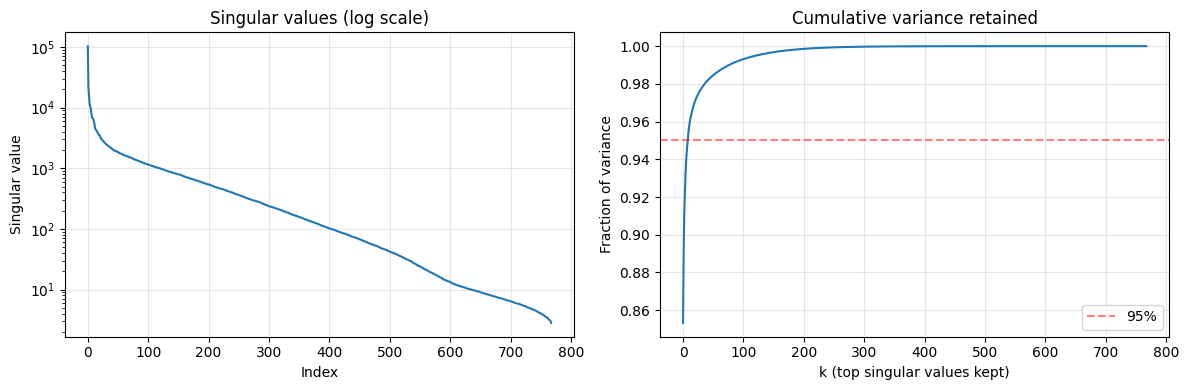

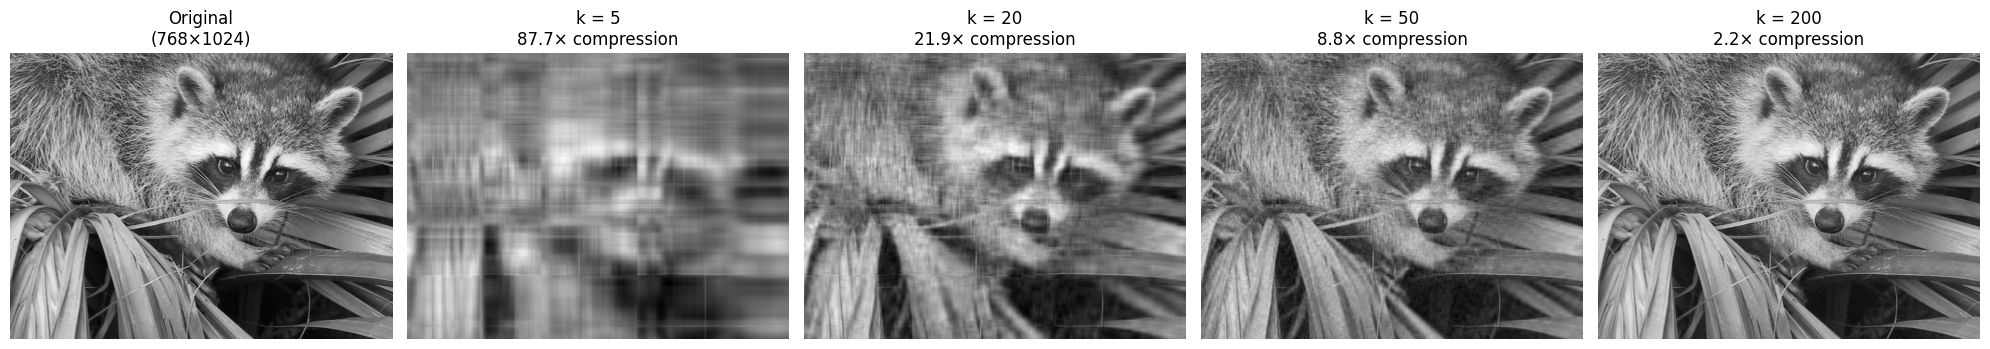

k      empirical error        predicted (Eckart-Young)
-------------------------------------------------------
5      29332.3191             29332.3191            
20     19337.3506             19337.3506            
50     13981.7719             13981.7719            
200    4248.6158              4248.6158             

The two columns match — Eckart-Young exactly predicts the error.


In [16]:
# Load a sample image
try:
    from scipy.datasets import face
    img = face(gray=True).astype(float)
except ImportError:
    np.random.seed(0)
    img = np.random.rand(512, 512) * 255

print('Image shape:', img.shape)

# Compute SVD
U, sv, Vt = np.linalg.svd(img, full_matrices=False)

# Singular values and cumulative variance
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.semilogy(sv)
plt.title('Singular values (log scale)')
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_variance = np.cumsum(sv**2) / np.sum(sv**2)
plt.plot(cumulative_variance)
plt.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95%')
plt.title('Cumulative variance retained')
plt.xlabel('k (top singular values kept)')
plt.ylabel('Fraction of variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Image compression at different k values
def rank_k_approximation(U, sv, Vt, k):
    return U[:, :k] @ np.diag(sv[:k]) @ Vt[:k, :]

k_values = [5, 20, 50, 200]
m, n = img.shape
original_size = m * n

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Original\n({m}×{n})')
axes[0].axis('off')

for idx, k in enumerate(k_values, start=1):
    img_k = rank_k_approximation(U, sv, Vt, k)
    compression = original_size / (k * (m + n + 1))
    
    axes[idx].imshow(img_k, cmap='gray')
    axes[idx].set_title(f'k = {k}\n{compression:.1f}× compression')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Verify the Eckart-Young theorem: error has a clean formula
# error = √(sum of squared discarded singular values)
print(f"{'k':<6} {'empirical error':<22} {'predicted (Eckart-Young)':<22}")
print('-' * 55)

for k in [5, 20, 50, 200]:
    img_k = rank_k_approximation(U, sv, Vt, k)
    empirical = np.linalg.norm(img - img_k, 'fro')
    predicted = np.sqrt(np.sum(sv[k:] ** 2))
    print(f'{k:<6} {empirical:<22.4f} {predicted:<22.4f}')

print()
print('The two columns match — Eckart-Young exactly predicts the error.')

## 5. Synthesis — When to Use Which Decomposition

After three weeks of linear algebra, the key skill is knowing which decomposition to reach for given a specific problem. Here's the decision tree:

### The decision tree

```
What kind of matrix are you working with?
│
├── Square AND symmetric?
│       └─→ Spectral theorem (np.linalg.eigh)
│           Fast, real eigenvalues, perpendicular eigenvectors
│
├── Square, diagonalizable, NOT symmetric?
│       └─→ Eigendecomposition (np.linalg.eig)
│           Useful for dynamics, Markov chains, PageRank
│
└── Non-square OR rank-deficient OR defective?
        └─→ SVD (np.linalg.svd)
            Universal — works for any matrix

Need to compress, denoise, or approximate?
    └─→ Low-rank approximation (SVD truncation)
```

### The grand unifying chain

For any square n × n matrix, these are all equivalent:

```
A is invertible
    ↔ det(A) ≠ 0
    ↔ rank(A) = n
    ↔ columns are linearly independent
    ↔ no zero eigenvalue
    ↔ A @ x = b has a unique solution for every b
```

Six statements, one geometric property viewed differently. The matrix decompositions of Week 3 are tools for revealing this structure.

### Where each decomposition shows up in real ML

| Decomposition | Real-world applications |
|---|---|
| Spectral theorem | PCA, covariance analysis, kernel methods, portfolio optimization |
| Eigendecomposition | PageRank, Markov chains, spectral clustering, dynamical systems |
| SVD | Recommendation systems, image compression, linear regression (via pseudoinverse) |
| Low-rank approximation | Image/video compression, model compression (LoRA), dimensionality reduction |

## Reflection — Week 3

Week 3 felt like the moment everything from Weeks 1 and 2 came together. Vectors, matrix multiplication, rank, determinants, eigenvalues — they all reappeared as ingredients in the decompositions we built.

A few moments stood out:

- **The spectral theorem clicked.** Once I saw that symmetric matrices guarantee real eigenvalues, perpendicular eigenvectors, and the cleaner formula A = Q · Λ · Qᵀ, I understood why ML keeps building around symmetric structures (covariance matrices, kernels, etc.). Symmetry isn't aesthetic — it's the property that makes the math work cleanly.

- **SVD's universality is the headline.** Eigendecomposition fails on defective matrices. The spectral theorem requires symmetry. But SVD just works — on any matrix, of any shape, in any condition. The trick is that SVD is built from the spectral decomposition of AᵀA and AAᵀ, both of which are always symmetric. SVD inherits its universality from the spectral theorem applied to symmetric companions.

- **Low-rank approximation revealed why real data is "easier than it looks."** When I saw an image compressed at rank 50 with barely any visible loss, I understood that real data lives in fewer effective dimensions than it appears. This is the foundation of PCA, recommendation systems, and model compression — and now it makes sense.

- **The decision tree synthesized everything.** By the end of the week, I could look at any matrix problem and know which decomposition to reach for. That's not memorization; that's the synthesis lens working.

### What's next

This concludes **Block 1 (Linear Algebra)** of Phase 1. The math foundation is now in place. Next comes:

- **Block 2 — Calculus & Gradients:** the math behind how models learn (gradient descent, partial derivatives, chain rule)
- **Block 3 — Probability & Statistics:** the language of uncertainty in ML
- **Block 4 — Information Theory:** entropy, cross-entropy, KL divergence
- **Phase 1 Capstone:** implement linear and logistic regression from scratch using everything learned

The decompositions of Week 3 will return constantly in Phase 2 — every PCA, every regression, every recommendation system rests on the foundations built this week.